In [3]:
import os
import cv2 as cv
import numpy as np
from matplotlib import pyplot as plt
from dotenv import load_dotenv
load_dotenv()
PROJECT_ROOT = os.environ.get("PROJECT_ROOT")

In [4]:
input_img = os.path.join(PROJECT_ROOT, "data", "processed", "extracted_lines","05_garde_001","05_garde_001_line_13.png")
img = cv.imread(input_img, cv.IMREAD_GRAYSCALE)

assert img is not None, "file could not be read, check with os.path.exists()"
# global thresholding
ret1,th1 = cv.threshold(img,127,255,cv.THRESH_BINARY)
# Otsu's thresholding
ret2,th2 = cv.threshold(img,0,255,cv.THRESH_BINARY+cv.THRESH_OTSU)
# Otsu's thresholding after Gaussian filtering
blur = cv.GaussianBlur(img,(5,5),0)
ret3,th3 = cv.threshold(blur,0,255,cv.THRESH_BINARY+cv.THRESH_OTSU)

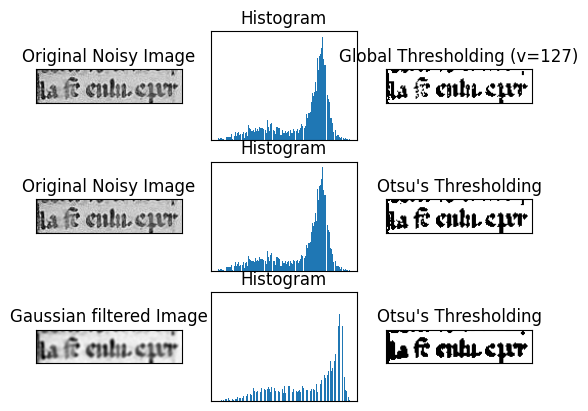

In [5]:
# plot all the images and their histograms
images = [img, 0, th1,
          img, 0, th2,
          blur, 0, th3]
titles = ['Original Noisy Image','Histogram','Global Thresholding (v=127)',
          'Original Noisy Image','Histogram',"Otsu's Thresholding",
          'Gaussian filtered Image','Histogram',"Otsu's Thresholding"]
for i in range(3):
    plt.subplot(3,3,i*3+1),plt.imshow(images[i*3],'gray')
    plt.title(titles[i*3]), plt.xticks([]), plt.yticks([])
    plt.subplot(3,3,i*3+2),plt.hist(images[i*3].ravel(),256)
    plt.title(titles[i*3+1]), plt.xticks([]), plt.yticks([])
    plt.subplot(3,3,i*3+3),plt.imshow(images[i*3+2],'gray')
    plt.title(titles[i*3+2]), plt.xticks([]), plt.yticks([])
plt.show()

In [4]:
def plot_binarize(input_img, gaussian_filter=(5,5)):
    img = cv.imread(input_img, cv.IMREAD_GRAYSCALE)

    assert img is not None, "file could not be read, check with os.path.exists()"
    
    # global thresholding
    ret1, th1 = cv.threshold(img, 127, 255, cv.THRESH_BINARY)
    # Otsu's thresholding
    ret2, th2 = cv.threshold(img, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)
    # Otsu's thresholding after Gaussian filtering
    blur = cv.GaussianBlur(img, gaussian_filter, 0)
    ret3, th3 = cv.threshold(blur, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)

    # Calculate figure size based on image aspect ratio
    height, width = img.shape
    aspect_ratio = width / height
    
    # Adjust figure size dynamically - wider for long images
    if aspect_ratio > 2:  # Very wide/long image
        fig_width = 20
        fig_height = 8
    elif aspect_ratio > 1:  # Moderately wide
        fig_width = 15
        fig_height = 7
    else:  # Square or tall image
        fig_width = 12
        fig_height = 9
    
    plt.figure(figsize=(fig_width, fig_height))
    
    # plot all the images and their histograms
    images = [img, 0, th1,
              img, 0, th2,
              blur, 0, th3]
    titles = ['Original Noisy Image', 'Histogram', 'Global Thresholding (v=127)',
              'Original Noisy Image', 'Histogram', "Otsu's Thresholding",
              'Gaussian filtered Image', 'Histogram', "Otsu's Thresholding"]
    
    for i in range(3):
        plt.subplot(3, 3, i*3+1)
        plt.imshow(images[i*3], 'gray')
        plt.title(titles[i*3])
        plt.xticks([])
        plt.yticks([])
        
        plt.subplot(3, 3, i*3+2)
        plt.hist(images[i*3].ravel(), 256)
        plt.title(titles[i*3+1])
        plt.xticks([])
        plt.yticks([])
        
        plt.subplot(3, 3, i*3+3)
        plt.imshow(images[i*3+2], 'gray')
        plt.title(titles[i*3+2])
        plt.xticks([])
        plt.yticks([])
    
    plt.tight_layout(pad=2.0)  # Add padding to prevent overlap
    plt.show()

**Gaussian filter (5,5)**

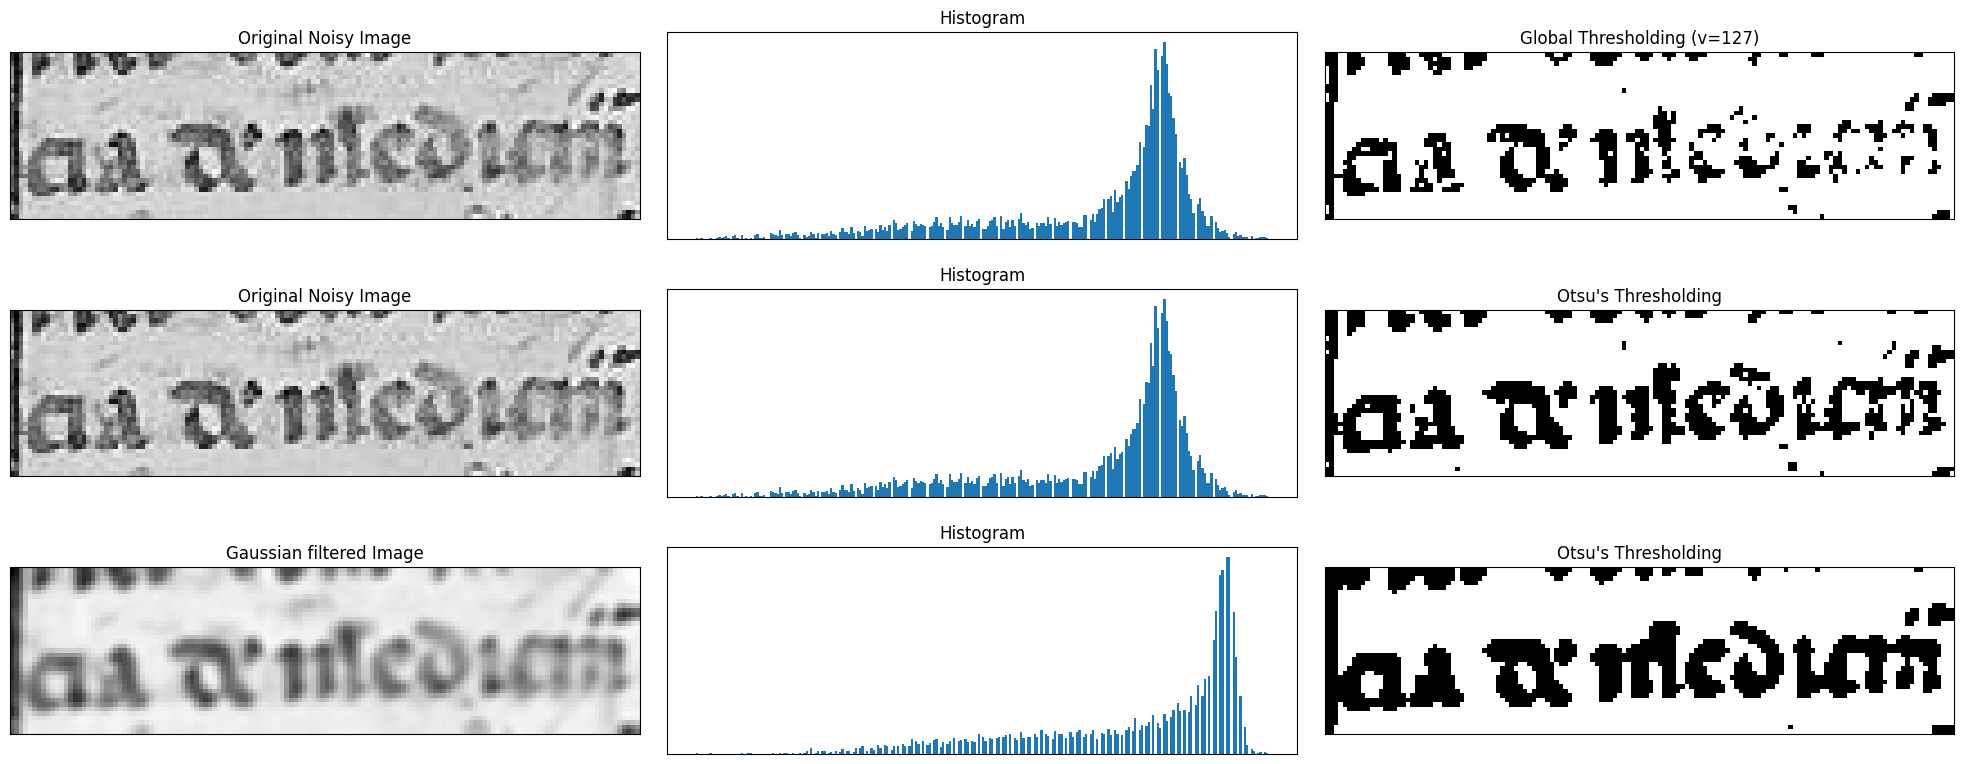

In [12]:
input_img = os.path.join(PROJECT_ROOT, "data", "processed", "extracted_lines","05_garde_001","05_garde_001_line_10.png")
plot_binarize(input_img)

**Gaussian filter (3,3)**

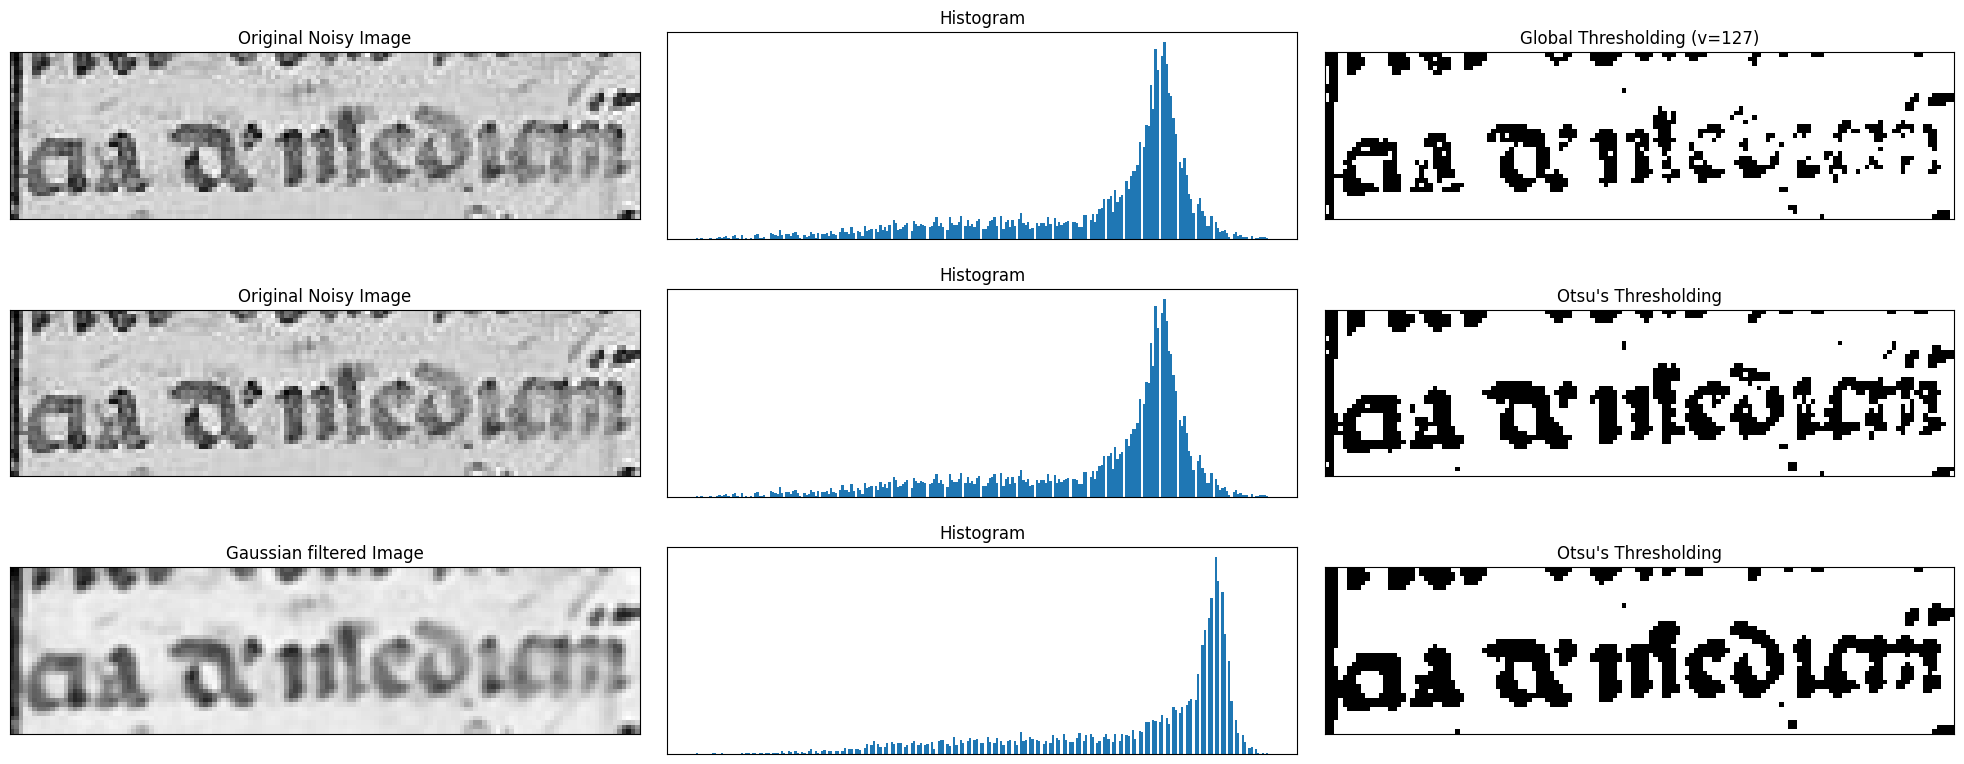

In [5]:
input_img = os.path.join(PROJECT_ROOT, "data", "processed", "extracted_lines","05_garde_001","05_garde_001_line_10.png")
plot_binarize(input_img, gaussian_filter=(3,3))

**Gaussian filter (1,3)**

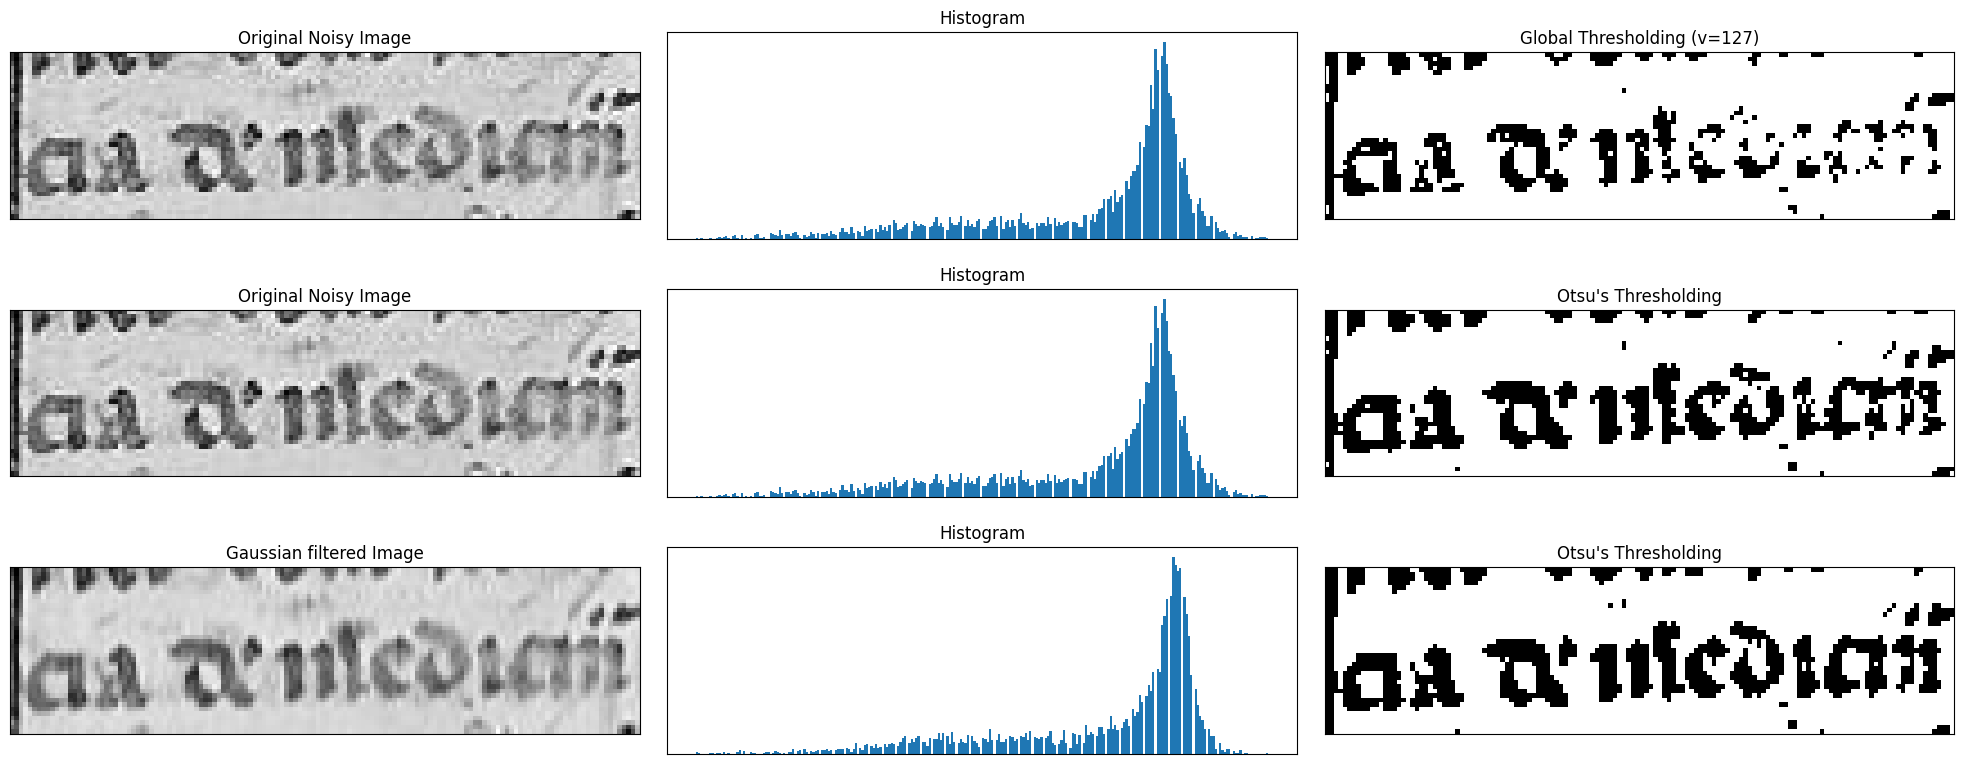

In [6]:
input_img = os.path.join(PROJECT_ROOT, "data", "processed", "extracted_lines","05_garde_001","05_garde_001_line_10.png")
plot_binarize(input_img, gaussian_filter=(1,3))

**Gaussian filter (3,1)**

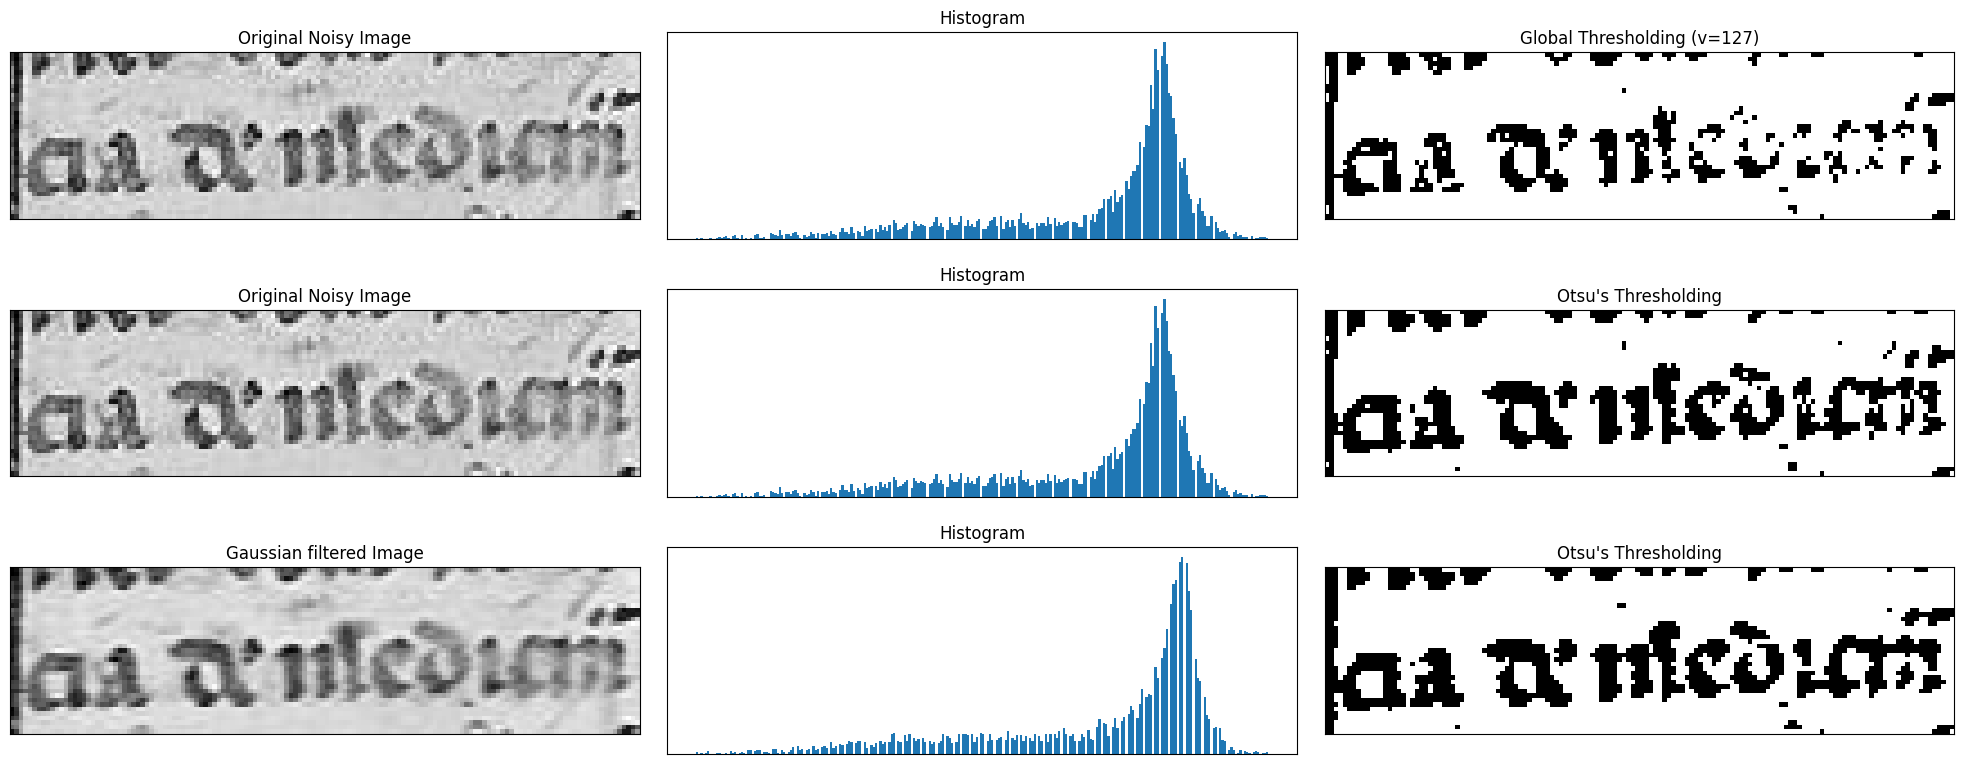

In [7]:
input_img = os.path.join(PROJECT_ROOT, "data", "processed", "extracted_lines","05_garde_001","05_garde_001_line_10.png")
plot_binarize(input_img, gaussian_filter=(3,1))

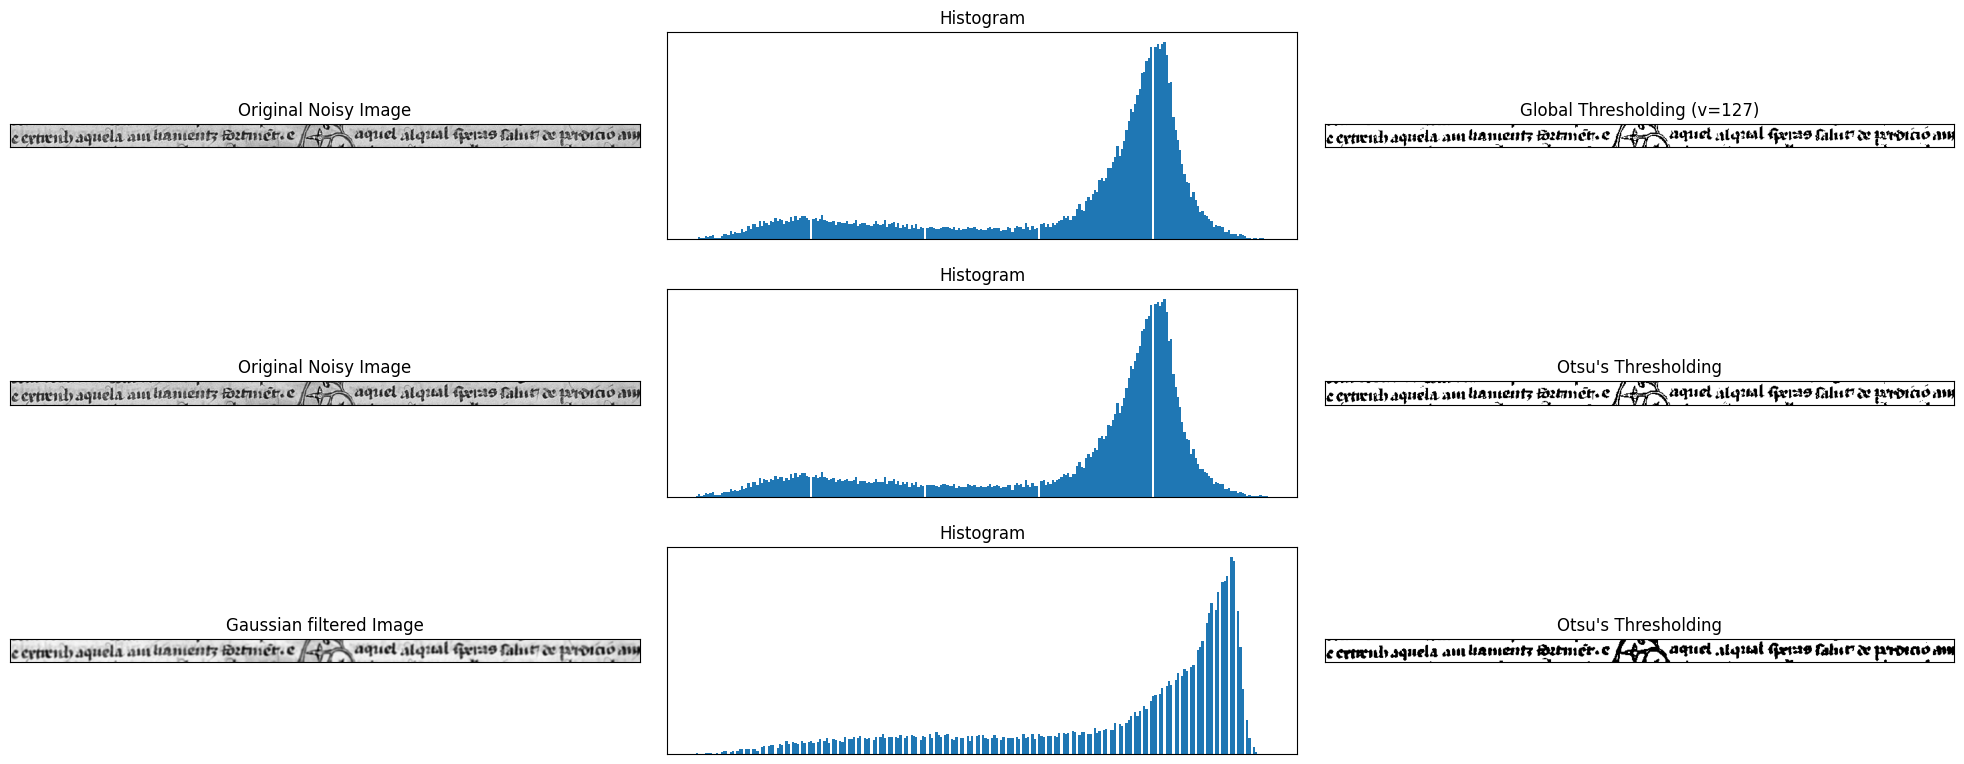

In [13]:
input_img = os.path.join(PROJECT_ROOT, "data", "processed", "extracted_lines","75_f_070v_garde","75_f_070v_garde_line_37.png")
plot_binarize(input_img)

**Plot function with histogram as a parameter**

In [24]:
def plot_binarize(input_img, show_histogram=True):
    img = cv.imread(input_img, cv.IMREAD_GRAYSCALE)

    assert img is not None, "file could not be read, check with os.path.exists()"
    
    # global thresholding
    ret1, th1 = cv.threshold(img, 127, 255, cv.THRESH_BINARY)
    # Otsu's thresholding
    ret2, th2 = cv.threshold(img, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)
    # Otsu's thresholding after Gaussian filtering
    blur = cv.GaussianBlur(img, (5, 5), 0)
    ret3, th3 = cv.threshold(blur, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)

    if show_histogram:
        # With histograms - 3x3 grid
        height, width = img.shape
        aspect_ratio = width / height
        
        if aspect_ratio > 2:
            fig_width = 20
            fig_height = 8
        elif aspect_ratio > 1:
            fig_width = 15
            fig_height = 7
        else:
            fig_width = 12
            fig_height = 9
        
        plt.figure(figsize=(fig_width, fig_height))
        
        images = [img, 0, th1,
                  img, 0, th2,
                  blur, 0, th3]
        titles = ['Original Noisy Image', 'Histogram', 'Global Thresholding (v=127)',
                  'Original Noisy Image', 'Histogram', "Otsu's Thresholding",
                  'Gaussian filtered Image', 'Histogram', "Otsu's Thresholding"]
        
        for i in range(3):
            plt.subplot(3, 3, i*3+1)
            plt.imshow(images[i*3], 'gray')
            plt.title(titles[i*3])
            plt.xticks([]), plt.yticks([])
            
            plt.subplot(3, 3, i*3+2)
            plt.hist(images[i*3].ravel(), 256)
            plt.title(titles[i*3+1])
            plt.xticks([]), plt.yticks([])
            
            plt.subplot(3, 3, i*3+3)
            plt.imshow(images[i*3+2], 'gray')
            plt.title(titles[i*3+2])
            plt.xticks([]), plt.yticks([])
        
        plt.tight_layout(pad=2.0)
        plt.show()
    
    else:
        # Without histograms - 2x2 grid for 4 images
        height, width = img.shape
        
        # Always use 2x2 layout for 4 images
        fig, axes = plt.subplots(2, 2, figsize=(15, 10))
        axes = axes.flatten()
        
        images = [img, th1, th2, th3]
        titles = ['Original Noisy Image', 'Global Thresholding (v=127)', 
                  "Otsu's Thresholding", "Otsu's Thresholding (Gaussian)"]
        
        for i, ax in enumerate(axes):
            ax.imshow(images[i], 'gray')
            ax.set_title(titles[i])
            ax.axis('off')
        
        plt.tight_layout()
        plt.show()

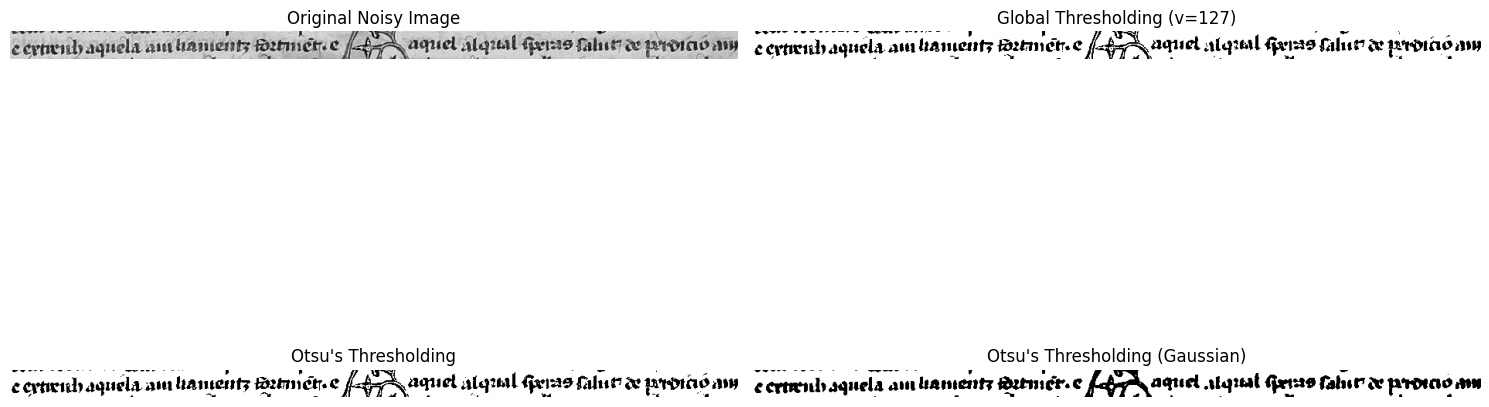

In [25]:
input_img = os.path.join(PROJECT_ROOT, "data", "processed", "extracted_lines","75_f_070v_garde","75_f_070v_garde_line_37.png")
plot_binarize(input_img, show_histogram=False)